## 2.2 Data Source Description

* **Data Source:** 
The dataset, titled "MyAnimeList Anime Data," originates from Kaggle. It consists of a single CSV file (`animes.csv`) containing comprehensive information scraped directly from **MyAnimeList (MAL)**, one of the world's largest active anime and manga communities. The dataset was last updated in November 2025.

* **Purpose of Collection:** 
To provide a structured dataset containing a wide range of data points—including broadcast details, genres, production studios, user scores, and engagement metrics—for analyzing trends, user preferences, and industry dynamics within the anime community.

* **The Collecting Entity:** 
The raw data is continually crowdsourced and maintained by the users and moderators of MyAnimeList.net. It was subsequently scraped, structured, and published by a Kaggle dataset creator. (All intellectual property rights belong to their respective owners).

* **Domain Knowledge & Personal Expertise:**
As an active user of the MyAnimeList platform, I have firsthand experience with how these metrics are generated. This domain knowledge allows for a deeper interpretation of the data structure:
  * **Score Skewness:** User profiles typically display a high personal mean score (often around 8.0), as users naturally choose shows they expect to enjoy. Consequently, a global `mean_score` of 7.0 on MAL is generally viewed by the community as average or mediocre rather than high.
  * **Status Mechanics & Ratings:** The platform tracks user interactions across categories (Completed, Watching, Dropped, On Hold). The global `mean_score` is predominantly influenced by users who "Completed" the show, whereas early "Dropped" ratings are often filtered out by MAL's scoring algorithm to prevent bias.
  * **Sequel Bias:** Direct sequels almost always achieve higher ratings than their original seasons, as the audience naturally narrows down to dedicated fans.
  * **Insights from Missing Data:** Older, obscure, or unreleased entries often lack complete attributes (such as `synopsis`, `start_date`, or `end_date`). Rather than being mere missing values, this absence highlights historical cataloging gaps and popular bias toward modern mainstream media.

## 3. Data Meta-Analysis
### 3.1 File Analysis

* **File Size:** 16.7 MB (16,698 KB). 
  * *Note: The original dataset on Kaggle is listed as 17.1 MB. The size was slightly reduced after removing unusual line terminators and hidden characters during initial local data cleaning in the code editor.*
* **Format:** CSV (Comma-Separated Values).
* **Creation Date:** 
  * **Original Data:** November 2025 (Last update and web scraping on Kaggle).
  * **Local File:** July 25, 2026 (Time of download and local environment setup).
* **Purpose of the Data:** The purpose of this dataset is to capture user engagement, rating distributions, and broadcasting details of various anime series to allow for industry trend analysis and community preference exploration.

In [17]:
# calling the pandas library
import pandas as pd

# Remove the default limit on displayed columns so we can view all columns without the hidden '...'
pd.set_option('display.max_columns', None)

# reading the dataset
anime_df = pd.read_csv(r'animes.csv', sep=',', index_col=0)

# 1. Number of rows and columns
print(f"Dataset Shape: {anime_df.shape}")
print(f"Number of Rows: {anime_df.shape[0]}")
print(f"Number of Columns: {anime_df.shape[1]}\n")

# 2. Column names and Data Types overview
print("--- Data Types and Missing Values ---")
anime_df.info()

Dataset Shape: (29375, 26)
Number of Rows: 29375
Number of Columns: 26

--- Data Types and Missing Values ---
<class 'pandas.DataFrame'>
Index: 29375 entries, 1 to 62976
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   title                             29375 non-null  str    
 1   picture                           29146 non-null  str    
 2   title_en                          12848 non-null  str    
 3   title_ja                          29198 non-null  str    
 4   start_date                        28504 non-null  str    
 5   end_date                          26389 non-null  str    
 6   synopsis                          24240 non-null  str    
 7   mean_score                        18947 non-null  float64
 8   rank                              22326 non-null  float64
 9   popularity                        29375 non-null  int64  
 10  nsfw                              29

### 3.2 Data Structure

* **Number of Rows and Columns:** 
Based on the programmatic output, the dataset consists of **29,375 rows** and **26 columns**.

* **Data Dictionary (Column Analysis):**
The column names are highly logical, descriptive, and follow the standard `snake_case` naming convention. Below is a breakdown of the columns and their purpose in the dataset:

  **1. Identifiers & Media Text:**
  * `title`, `title_en`, `title_ja`: The official, English, and Japanese names of the anime. Crucial for localization and text analysis.
  * `picture`: URL to the anime's poster image.
  * `synopsis`: A text summary of the plot. Used for Natural Language Processing (NLP) or keyword extraction.

  **2. Release & Format Metadata:**
  * `media_type`: The format of the anime (e.g., TV, Movie, OVA).
  * `start_date` & `end_date`: The broadcasting timeframe.
  * `status`: Current airing status (e.g., Finished Airing, Currently Airing).
  * `num_episodes` & `average_episode_duration_seconds`: Determines the total length and pacing of the show.

  **3. Content Characteristics:**
  * `genres`: Categories describing the anime's themes (e.g., Action, Romance).
  * `studios`: The animation studios responsible for production.
  * `source`: The original material the anime is based on (e.g., Manga, Light Novel, Original).
  * `rating` & `nsfw`: Age rating and Not-Safe-For-Work flags for content filtering.

  **4. Community & Engagement Metrics (The Core Target):**
  * `mean_score` & `num_scoring_users`: The average rating and the number of users who contributed to it.
  * `rank` & `popularity`: The mathematical tier of the anime versus its raw popularity.
  * **Status Metrics** (`num_list_users`, `watching`, `completed`, `on_hold`, `dropped`, `plan_to_watch`): Detailed breakdown of user engagement and retention. These explain *how* the audience interacts with the show over time.

* **Data Types and Insights for Future Code:**
Looking at the output of `anime_df.info()`, the data types consist of integers/floats (for scores, episodes, and ranks) and `object` types (strings) for titles, genres, and dates. 
**Crucial insights for Data Cleaning:**
  1. **Date Conversion:** The date columns (`start_date` and `end_date`) are currently stored as `object` (strings). To perform time-series analysis or filter by years, these columns must be explicitly converted into `datetime` objects.
  2. **Logical Missing Values:** A comparison of non-null counts shows a clear gap: `start_date` has 28,504 records while `end_date` has only 26,389. This discrepancy is a valuable structural insight, indicating the presence of ongoing or currently airing anime series where the broadcast has not yet concluded, leaving the end date values as inherently missing (`NaN`).

* **Discussion: Research vs. Operations and Potential Biases:**
  * **Collection Purpose:** The data was originally generated for **operations**. MyAnimeList uses this data organically to run its platform, allowing users to track their watchlists and providing community features. It was retroactively scraped and compiled into a CSV format for **research** purposes.
  * **Potential Biases:**
    1. **Self-Selection Bias:** Users only rate shows they actively choose to watch. Shows with niche audiences might have artificially high scores because only dedicated fans watch and rate them.
    2. **Sequel Bias (Survival Bias):** Sequel seasons almost always score higher. Viewers who disliked the first season "drop" the show and do not rate the sequel, leaving only a concentrated group of fans to rate the newer seasons.
    3. **Popularity/Mainstream Bias:** The `popularity` metric is heavily skewed toward modern, accessible shounen anime, potentially overshadowing critically acclaimed but older or obscure series.

In [18]:
# 1. Check every cell for missing values (NaN) and sum them up for each column
missing_data = anime_df.isnull().sum()

# 2. Calculate the percentage of missing values by dividing by the total number of rows and multiplying by 100
missing_percent = (missing_data / len(anime_df)) * 100

# 3. Create a new organized DataFrame (table) to hold our counts and percentages side by side
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})

# 4. Filter out columns with 0 missing values (irrelevant data) to reduce visual noise, then sort the remaining ones from highest percentage to lowest
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

# 5. Print a title and display the final summary table neatly in the notebook
print("--- Extent of Missing Data ---")
display(missing_df)

--- Extent of Missing Data ---


,Missing Values,Percentage (%)
title_en,16527,56.262128
studios,11948,40.674043
mean_score,10428,35.499574
rank,7049,23.996596
synopsis,5135,17.480851
end_date,2986,10.165106
source,2772,9.436596
start_date,871,2.965106
rating,604,2.056170
picture,229,0.779574


### 4. Data Quality and Completeness
#### 4.1 Missing Data Analysis

*   **Extent of Missing Data:**
    Based on the programmatic analysis, 11 out of the 26 columns contain missing values. The most significant missing data appears in attributes such as `title_en` (56.26%), `studios` (40.67%), `mean_score` (35.50%), and `rank` (24.00%). Additionally, the `end_date` column is missing 10.17% of its values.

*   **Missing Data Pattern (Random vs. Structured):**
    The missing data pattern in this dataset is highly **structured** (Missing Not At Random - MNAR). The absence of data is not due to arbitrary scraping errors, but rather reflects the inherent mechanics of the anime industry, the platform's rating algorithms, and the historical nature of the media.

*   **What can be inferred from the missing data?**
    The missing values act as implicit data points, offering several domain-specific insights:
    *   *Missing `title_en` (56%) & `studios` (41%):* Demonstrates that more than half of the database consists of domestic, older, or obscure Japanese media that never received official Western localization or proper production documentation.
    *   *Missing `mean_score` (35%) & `rank` (24%):* The platform's algorithm requires a minimum threshold of user engagement to calculate a global mean or rank. A missing score indicates a show with extremely low popularity or a title that has not yet aired.
    *   *Missing `end_date` (10%):* As observed previously, this indicates the anime is currently airing ("Ongoing") or was canceled abruptly without a formal conclusion.

*   **How would you impute/fill the missing data?**
    Standard statistical imputation methods (like filling with the global mean) would be incorrect here because they would severely distort reality (e.g., giving an unrated, obscure show an "average" score of 7.0).
    *   **Categorical/Text Data (`title_en`, `synopsis`, `studios`):** Fill with a constant placeholder such as "Unknown" or "Not Available". For `title_en`, a valid strategy is to backfill missing entries using the original romanized `title`.
    *   **Dates (`end_date`):** Leave as `NaN` (which inherently represents an 'Ongoing' status) or fill with a specific categorical flag value like "Ongoing".
    *   **Numerical Scores (`mean_score`, `rank`):** Do not impute with the global average. It is best to leave them as `NaN` to avoid artificially skewing the dataset. If an algorithm strictly requires numbers, they should be flagged with an unnatural value (e.g., `-1`).

In [19]:
# 1. Check for full duplicates (all columns are identical)
full_duplicates = anime_df.duplicated().sum()

# 2. Check for TRUE partial duplicates (same ID, but different data)
# Create a temporary dataframe without the full duplicates to avoid false positives
df_no_full = anime_df.drop_duplicates()

# Count how many duplicated IDs remain in the cleaned dataframe
true_partial_duplicates = df_no_full.index.duplicated().sum()

print("--- Duplicates Analysis ---")
print(f"Full Duplicates: {full_duplicates}")
print(f"True Partial Duplicates (Same ID, Different Data): {true_partial_duplicates}")

# Optional: Display the true partial duplicates
if true_partial_duplicates > 0:
    print("\nExample of TRUE Partial Duplicates:")
    # Find and display all rows of the true partial duplicates, sorted by ID
    true_partials = df_no_full[df_no_full.index.duplicated(keep=False)].sort_index()
    display(true_partials)

--- Duplicates Analysis ---
Full Duplicates: 66
True Partial Duplicates (Same ID, Different Data): 4

Example of TRUE Partial Duplicates:


,title,picture,title_en,title_ja,start_date,end_date,synopsis,mean_score,rank,popularity,nsfw,media_type,status,genres,num_episodes,source,average_episode_duration_seconds,rating,studios,num_list_users,num_scoring_users,watching,completed,on_hold,dropped,plan_to_watch
id,,,,,,,,,,,,,,,,,,,,,,,,,,
18,Initial D Fourth Stage,https://cdn.myanimelist.net/images/anime/9/105...,NaN,頭文字〈イニシャル〉D FOURTH STAGE,2004-04-17,2006-02-18,Takumi Fujiwara finally joins Ryousuke and Kei...,8.17,456.0,1291,False,tv,finished_airing,"Action,Drama,Racing,Seinen",24,manga,1620,pg_13,A.C.G.T.,209134,116263,12309,158188,5512,2378,30734
18,Initial D Fourth Stage,https://cdn.myanimelist.net/images/anime/9/105...,NaN,頭文字〈イニシャル〉D FOURTH STAGE,2004-04-17,2006-02-18,Takumi Fujiwara finally joins Ryousuke and Kei...,8.17,455.0,1291,False,tv,finished_airing,"Action,Drama,Racing,Seinen",24,manga,1620,pg_13,A.C.G.T.,209134,116263,12309,158188,5512,2378,30734
29,Zipang,https://cdn.myanimelist.net/images/anime/13/75...,NaN,ジパング,2004-10-08,2005-04-01,A Ripple in Time Turns the Crucial Tide of WWI...,7.49,2073.0,4901,False,tv,finished_airing,"Action,Adult Cast,Drama,Historical,Military,Sc...",26,manga,1450,pg_13,Studio Deen,24875,8438,1469,9764,992,944,11699
29,Zipang,https://cdn.myanimelist.net/images/anime/13/75...,NaN,ジパング,2004-10-08,2005-04-01,A Ripple in Time Turns the Crucial Tide of WWI...,7.49,2073.0,4901,False,tv,finished_airing,"Action,Adult Cast,Drama,Historical,Military,Sc...",26,manga,1450,pg_13,Studio Deen,24875,8438,1469,9764,992,944,11699
65,Rozen Maiden: Träumend,https://cdn.myanimelist.net/images/anime/4/102...,Rozen Maiden: Träumend,ローゼンメイデン トロイメント,2005-10-21,2006-01-27,"As the story of Rozen Maiden closes, a new cha...",7.61,1602.0,2179,False,tv,finished_airing,"Action,Drama,Seinen,Supernatural",12,manga,1460,pg_13,Nomad,110089,61069,2809,84859,2396,1965,18052
65,Rozen Maiden: Träumend,https://cdn.myanimelist.net/images/anime/4/102...,Rozen Maiden: Träumend,ローゼンメイデン トロイメント,2005-10-21,2006-01-27,"As the story of Rozen Maiden closes, a new cha...",7.61,1602.0,2179,False,tv,finished_airing,"Action,Drama,Seinen,Supernatural",12,manga,1460,pg_13,Nomad,110089,61069,2809,84859,2396,1965,18052
69,Cluster Edge,https://cdn.myanimelist.net/images/anime/1980/...,NaN,CLUSTER EDGE（クラスターエッジ）,2005-10-05,2006-03-29,Cluster Edge Academy isn't just any school; it...,6.30,8513.0,6588,False,tv,finished_airing,"Action,Fantasy,Military,Sci-Fi",25,original,1440,pg_13,Sunrise,11777,3437,662,3853,700,1076,5485
69,Cluster Edge,https://cdn.myanimelist.net/images/anime/1980/...,NaN,CLUSTER EDGE（クラスターエッジ）,2005-10-05,2006-03-29,Cluster Edge Academy isn't just any school; it...,6.30,8514.0,6588,False,tv,finished_airing,"Action,Fantasy,Military,Sci-Fi",25,original,1440,pg_13,Sunrise,11777,3437,662,3853,700,1076,5485


### 4.2 Data Duplication

*   **Full Duplicates:** 
    Based on the code analysis using `anime_df.duplicated()`, there are **66** full duplicate rows in the dataset where every single column matches exactly.
*   **Partial Duplicates:** 
    Using the unique `id` (the dataframe's index) as a strict identifier rather than the title, and after filtering out the full duplicates, we found exactly **4** true partial duplicates (representing 4 specific anime rows, or 2 unique anime entities). These are rows that represent the exact same anime entity but have slight discrepancies in other columns, such as minor shifts in the `rank` metric over time (e.g., ID 18's rank shifting from 456 to 455).
    *(Note: Initial analysis by title yielded more duplicates, but several were false positives caused by different anime sharing the exact same name, highlighting the critical importance of using the `id` for duplicate resolution).*

*   **What can be inferred from these duplicates?**
    *   *Full Duplicates:* These are technical artifacts from the data collection process (Web Scraping). It typically happens when the scraper accidentally visits, records, and saves the same MyAnimeList webpage more than once.
    *   *Partial Duplicates:* These occur when the scraper extracts data from the exact same anime page, but at slightly different points in time. Because metrics like `rank`, `watching`, or `mean_score` update constantly as users interact with the live site, the scraper captures the exact same anime with slightly updated community statistics.

*   **Should the duplicates be removed or handled differently?**
    Yes, they must be handled and removed to prevent statistical bias during the Exploratory Data Analysis (EDA) phase. 
    *   **Full Duplicates** should be entirely removed using `anime_df.drop_duplicates(inplace=True)`, as they provide zero additional value and only skew the statistical distribution.
    *   **Partial Duplicates** should be resolved intelligently. Since they share the same unique `id`, we keep only the most relevant record. We rely on the logical assumption that the data was scraped chronologically (meaning later rows in the dataset represent newer extractions). Therefore, we retain the row with the most up-to-date metrics (the last occurrence) and remove older versions using the command `anime_df = anime_df[~anime_df.index.duplicated(keep='last')]` (where `keep='last'` marks older duplicates for removal, and the `~` operator inverts the boolean mask to keep only the unique/latest rows).

In [ ]:
print("--- 1. Checking Zeros in 'num_episodes' & Context ---")
if 'num_episodes' in anime_df.columns:
    zeros_mask = (anime_df['num_episodes'] == 0)
    print(f"Total anime with 0 episodes: {zeros_mask.sum()}")
    if 'status' in anime_df.columns and zeros_mask.sum() > 0:
        print("Status breakdown for anime with 0 episodes:")
        print(anime_df[zeros_mask]['status'].value_counts())

print("\n--- 2. Checking Missing (NaN) Values in Critical Columns ---")
critical_cols = ['title', 'status', 'media_type', 'num_episodes']
for col in critical_cols:
    if col in anime_df.columns:
        print(f"Missing values in '{col}': {anime_df[col].isna().sum()}")

print("\n--- 3. Checking Logical Inconsistencies (Status vs Dates) ---")
if 'status' in anime_df.columns and 'end_date' in anime_df.columns:
    finished_no_end = anime_df[(anime_df['status'] == 'finished_airing') & (anime_df['end_date'].isna())]
    print(f"Finished anime missing an end date: {len(finished_no_end)}")

if 'status' in anime_df.columns and 'start_date' in anime_df.columns:
    airing_no_start = anime_df[(anime_df['status'] == 'currently_airing') & (anime_df['start_date'].isna())]
    print(f"Currently airing anime missing a start date: {len(airing_no_start)}")

print("\n--- 4. Checking Negative Numbers in Numeric Columns ---")
numeric_cols = anime_df.select_dtypes(include=['number']).columns
negative_counts = (anime_df[numeric_cols] < 0).sum()
cols_with_negatives = negative_counts[negative_counts > 0]
print(cols_with_negatives if not cols_with_negatives.empty else "No negative values found in any numeric column.")

print("\n--- 5. Checking User Metrics Hierarchy (Logical Consistency) ---")
if all(col in anime_df.columns for col in ['num_list_users', 'num_scoring_users', 'watching']):
    hierarchy_violations = anime_df[
        (anime_df['num_list_users'] < anime_df['num_scoring_users']) | 
        (anime_df['num_list_users'] < anime_df['watching'])
    ]
    print(f"Rows violating user metrics hierarchy: {len(hierarchy_violations)}")
else:
    print("Some user metric columns are missing.")

print("\n--- 6. Checking Extreme Outliers ---")
if 'mean_score' in anime_df.columns:
    invalid_scores = anime_df[(anime_df['mean_score'] < 0) | (anime_df['mean_score'] > 10)]
    print(f"Anime with invalid mean_score (out of 0-10 range): {len(invalid_scores)}")

if 'num_episodes' in anime_df.columns:
    extreme_episodes = anime_df[anime_df['num_episodes'] > 2000]
    print(f"Anime with extreme episode counts (>2000): {len(extreme_episodes)}")

print("\n--- 7. Checking Empty or Whitespace-only Titles ---")
if 'title' in anime_df.columns:
    empty_titles = (anime_df['title'].str.strip() == '').sum()
    print(f"Anime with empty or whitespace-only titles: {empty_titles}")

--- 1. Checking Zeros in 'num_episodes' & Context ---
Total anime with 0 episodes: 747
Status breakdown for anime with 0 episodes:
status
not_yet_aired       468
currently_airing    276
finished_airing       3
Name: count, dtype: int64

--- 2. Checking Missing (NaN) Values in Critical Columns ---
Missing values in 'title': 0
Missing values in 'status': 0
Missing values in 'media_type': 0
Missing values in 'num_episodes': 0

--- 3. Checking Logical Inconsistencies (Status vs Dates) ---
Finished anime missing an end date: 2117
Currently airing anime missing a start date: 0

--- 4. Checking Negative Numbers in Numeric Columns ---
No negative values found in any numeric column.

--- 5. Checking User Metrics Hierarchy (Logical Consistency) ---
Rows violating user metrics hierarchy: 0

--- 6. Checking Extreme Outliers ---
Anime with invalid mean_score (out of 0-10 range): 0
Anime with extreme episode counts (>2000): 1

--- 7. Checking Empty or Whitespace-only Titles ---
Anime with empty or w

### 4.3 Suspicious / Anomalous Values

*   **Impossible Values & Contextual Zeros (`num_episodes`):** 
    We examined numeric boundaries for logical impossibilities and found no negative values across any numeric columns. For zeros, contextual cross-validation was performed: out of **747** anime with 0 episodes, the vast majority are logically sound (**468** are `not_yet_aired` and **276** are `currently_airing`, where final episode counts are not yet available). However, **3** anime incorrectly marked as `finished_airing` still had 0 episodes, representing minor scraping anomalies.
*   **Missing Data in Critical Fields:** 
    A check for missing (`NaN`) values in essential columns (`title`, `status`, `media_type`, `num_episodes`) showed **0 missing values**, confirming a structurally robust core dataset.
*   **Logical Inconsistencies (Status vs. Dates):** 
    We cross-referenced `status` and chronological dates. We found **2,117** anime marked as `finished_airing` that lack an `end_date`. Looking at a sample of these flagged rows revealed that they frequently correspond to very old historical titles (such as silent films from 1917). This indicates that the missing end dates stem from historical metadata documentation gaps in the original source rather than a programmatic bug. No currently airing anime lacked a start date.
*   **User Metrics Hierarchy & Outliers:** 
    *   *User Metrics Consistency:* We verified that community metrics follow a logical hierarchy (e.g., `num_list_users` must be greater than or equal to `num_scoring_users` and `watching`). The check confirmed **0 hierarchy violations**.
    *   *Outliers & Text Anomalies:* No invalid mean scores (out of the 0-10 range) and zero whitespace-only titles were found. Only **1** anime had an extreme episode count exceeding 2,000, representing a long-running long-form series rather than a data corruption.
*   **What do these values tell us about the data?**
    These findings demonstrate that the dataset is structurally clean and logically consistent in its core fields. The detected edge cases—such as missing historical end dates based on a review of sampled rows, or rare status mismatches for unreleased shows—reflect real-world data collection boundaries and historical documentation gaps rather than technical corruptions, ensuring they can be properly accounted for during EDA.

In [24]:
# Calculate unique values, missing values, and percentage (ratio)
cardinality_df = pd.DataFrame({
    'Unique_Values': anime_df.nunique(),
    'Missing_Values': anime_df.isna().sum(),
    'Total_Rows': len(anime_df)
})

# Calculate cardinality percentage
cardinality_df['Cardinality_Percentage'] = (cardinality_df['Unique_Values'] / cardinality_df['Total_Rows']) * 100

# Format the percentage to display nicely with '%' sign
cardinality_df['Cardinality_%'] = cardinality_df['Cardinality_Percentage'].round(3).astype(str) + '%'

print("--- 1. Columns with Zero Variance (Single Unique Value) ---")
single_value_cols = cardinality_df[cardinality_df['Unique_Values'] <= 1]
print(single_value_cols if not single_value_cols.empty else "None found (all columns have variance - 0%).")

print("\n--- 2. Full Cardinality Summary (Sorted by Unique Values) ---")
summary_sorted = cardinality_df[['Unique_Values', 'Cardinality_%']].sort_values(by='Unique_Values', ascending=False)
display(summary_sorted)

--- 1. Columns with Zero Variance (Single Unique Value) ---
None found (all columns have variance - 0%).

--- 2. Full Cardinality Summary (Sorted by Unique Values) ---


,Unique_Values,Cardinality_%
title,29298,99.738%
picture,29079,98.992%
title_ja,28063,95.534%
synopsis,23899,81.358%
popularity,23073,78.546%
rank,17997,61.266%
title_en,12586,42.846%
num_list_users,12349,42.039%
completed,10081,34.318%
start_date,9694,33.001%


### 4.4 Cardinality

*   **Columns with Zero Variance (Single Unique Value):** 
    We checked for constant columns where all rows share the exact same value. The analysis returned **none found**, meaning every column in the dataset exhibits variability and contributes potential information.
*   **Columns with High Cardinality (Unique / Near-Unique Values):** 
    *   *High Cardinality Features:* Columns such as `title` (**99.738%** unique), `picture` (**98.992%**), and `title_ja` (**95.534%**) exhibit extremely high cardinality, reflecting unique identifiers or names for individual anime entities. Other descriptive text fields like `synopsis` also show high diversity (**81.358%**).
    *   *Low/Moderate Cardinality Features:* In contrast, categorical and grouped features have very low cardinality percentages (e.g., `source` at **0.054%**, `media_type` at **0.034%**, `rating` at **0.020%**, `status` at **0.010%**, and `nsfw` at **0.007%**), which is completely expected for categorical groupings.
*   **What can be inferred from these cardinalities?**
    The lack of zero-variance columns confirms that no redundant, static columns need to be dropped prior to analysis. High-cardinality text fields (such as titles) serve as primary identifiers rather than direct statistical features, while low-cardinality categorical variables will be essential for grouping, aggregation, and categorical analysis during the EDA phase.

In [25]:
import pandas as pd
import numpy as np

# Step 1: Automatically select all columns with numeric data types (int64, float64, etc.) from the dataset
numeric_cols = anime_df.select_dtypes(include=['number']).columns.tolist()

# Create an empty DataFrame to store all statistical metrics for each column
summary_stats = pd.DataFrame(index=numeric_cols)

# Loop through each numeric variable to compute the required metrics
for col in numeric_cols:
    # Extract the series for the column and drop missing values (NaN) to avoid distorted calculations
    s = anime_df[col].dropna()
    
    if len(s) == 0:
        continue # Skip if the column is entirely empty
        
    # --- Part A: Centrality & Dispersion (Standard & Robust) ---
    summary_stats.loc[col, 'Mean'] = s.mean()       # Arithmetic mean
    summary_stats.loc[col, 'Median'] = s.median()   # Median (Robust centrality measure)
    summary_stats.loc[col, 'Std'] = s.std()         # Standard deviation
    summary_stats.loc[col, 'Min'] = s.min()         # Minimum value
    summary_stats.loc[col, 'Max'] = s.max()         # Maximum value
    
    # Compute quantiles and robust dispersion measures (IQR & MAD)
    Q1 = s.quantile(0.25)                           # First quartile (25th percentile)
    Q3 = s.quantile(0.75)                           # Third quartile (75th percentile)
    IQR = Q3 - Q1                                   # Interquartile Range (Robust dispersion measure)
    summary_stats.loc[col, 'IQR'] = IQR
    summary_stats.loc[col, 'MAD'] = (s - s.median()).abs().median() # Median Absolute Deviation (Another robust dispersion measure)
    
    # --- Part B: Skewness & Bowley/Galton Measure ---
    summary_stats.loc[col, 'Skewness'] = s.skew()   # Classical skewness metric
    
    # Compute Bowley's Skewness measure based on quartiles and the median
    # Formula: (Q3 + Q1 - 2*Median) / IQR
    if IQR > 0:
        summary_stats.loc[col, 'Bowley_Skew'] = (Q3 + Q1 - 2 * s.median()) / IQR
    else:
        summary_stats.loc[col, 'Bowley_Skew'] = 0

    # --- Part C: Outlier Detection Using Three Different Methods ---
    
    # Method 1: IQR Rule (Values falling beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR)
    iqr_outliers = s[(s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)]
    summary_stats.loc[col, 'IQR_Outliers_Count'] = len(iqr_outliers)
    
    # Method 2: Z-Score Rule (Checking if a value is more than 3 standard deviations away from the mean: |Z| > 3)
    if s.std() > 0:
        z_scores = (s - s.mean()) / s.std()
        z_outliers = s[abs(z_scores) > 3]
        summary_stats.loc[col, 'ZScore_Outliers_Count'] = len(z_outliers)
    else:
        summary_stats.loc[col, 'ZScore_Outliers_Count'] = 0
    
    # Method 3: Percentile Rule (Counting values falling outside the 1st and 99th percentiles)
    p1 = s.quantile(0.01)
    p99 = s.quantile(0.99)
    pct_outliers = s[(s < p1) | (s > p99)]
    summary_stats.loc[col, 'Percentile_Outliers_Count'] = len(pct_outliers)

# Print and display the final summary table containing all computed metrics for all numeric variables
print(f"--- Univariate Analysis Summary for ALL {len(numeric_cols)} Numeric Columns ---")
display(summary_stats[['Mean', 'Median', 'Std', 'IQR', 'MAD', 'Skewness', 'Bowley_Skew', 
                       'IQR_Outliers_Count', 'ZScore_Outliers_Count', 'Percentile_Outliers_Count']])

--- Univariate Analysis Summary for ALL 12 Numeric Columns ---


,Mean,Median,Std,IQR,MAD,Skewness,Bowley_Skew,IQR_Outliers_Count,ZScore_Outliers_Count,Percentile_Outliers_Count
mean_score,6.394510,6.36,0.894978,1.26,0.63,-0.020539,0.063492,102.0,61.0,374.0
rank,10926.848562,10903.50,6502.497393,11285.75,5644.00,0.008492,0.003256,0.0,0.0,223.0
popularity,14454.396085,14434.00,8570.640597,14873.00,7436.00,0.007072,0.001479,0.0,0.0,294.0
num_episodes,13.642996,1.00,46.306385,11.00,1.00,24.627242,1.000000,3202.0,238.0,286.0
average_episode_duration_seconds,1232.727728,818.00,1450.663196,1240.00,622.00,2.205086,0.051613,2538.0,883.0,287.0
num_list_users,39048.838809,1032.00,169427.989464,8875.00,942.00,9.875459,0.817239,5137.0,451.0,294.0
num_scoring_users,19722.611745,293.00,100777.402206,3156.00,279.00,12.015996,0.849176,5207.0,393.0,294.0
watching,2670.757345,55.00,19796.907252,477.00,52.00,58.982676,0.811321,4854.0,218.0,294.0
completed,24966.803336,409.00,124584.198509,4247.50,382.00,11.840290,0.845085,5188.0,394.0,294.0
on_hold,997.099506,21.00,5526.792052,225.00,20.00,22.109354,0.848889,4666.0,325.0,294.0


### 5.1 Numeric Variables

*   **Centrality & Dispersion (Standard vs. Robust Measures):** 
    We analyzed 12 numeric variables, comparing standard metrics (Mean, Std) with robust measures (Median, IQR, and Median Absolute Deviation - MAD). For community and engagement metrics (e.g., `num_list_users`, `completed`, `num_episodes`), a large gap between the mean and median indicates severe asymmetry. For instance, `num_list_users` has a mean of ~39,048 but a median of 1,032, showing that robust measures are essential to properly represent the central tendency without being skewed by blockbuster titles.
*   **Skewness & Distribution:** 
    *   *Right-Skewed Distributions:* Metrics such as `num_episodes`, `num_list_users`, and active status counts (`watching`, `completed`) exhibit high positive classical skewness and Bowley skewness values close to 1, reflecting long right tails where a small number of titles attract massive engagement.
    *   *Symmetric Distributions & Scores:* In contrast, `mean_score` displays an approximately symmetric, bell-shaped distribution centered around a mean and median of ~6.4.
*   **Explanation of Score Bias (`mean_score`):** 
    The phenomenon where the average score tends to be relatively high and concentrates around a score of 7 reflects a natural selection bias in community-based systems. Viewers naturally tend to watch and rate series they already connect with or whose genres they enjoy, whereas poor series or those of little interest to the audience are usually ignored and unwatched, preventing a uniform distribution and skewing scores upward.
*   **Univariate Outlier Detection (3 Methods):** 
    We applied three distinct methods to detect outliers: the IQR rule, Z-score threshold ($|Z| > 3$), and extreme percentile boundaries (1st and 99th percentiles). 
    *   For heavy-tailed engagement metrics, the IQR method flagged thousands of high-end outliers due to the dense concentration of niche titles versus highly popular hits.
    *   For bounded or normally distributed metrics like `mean_score`, the outlier counts remained well-contained across the methods (e.g., 102 via IQR, 61 via Z-score, and 374 via percentiles).
*   **What do these distributions tell us?**
    The numeric variables reveal a dual nature in the dataset: quality metrics (like scores) behave in a balanced, roughly normal manner, while popularity and scale metrics (like views, lists, and episodes) follow heavily skewed power-law-like distributions, requiring careful consideration during scaling and modeling phases.

In [26]:
# Automatically select all categorical/string/boolean columns
categorical_cols = anime_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Let's inspect the categorical summary for each column
for col in categorical_cols:
    s = anime_df[col].dropna()
    if len(s) == 0:
        continue
        
    print(f"\n========================================")
    print(f"Feature: {col}")
    print(f"========================================")
    
    # Value counts and percentages
    counts = s.value_counts()
    percentages = s.value_counts(normalize=True) * 100
    
    summary_cat = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2),
        'Cumulative Percentage (%)': percentages.cumsum().round(2)
    })
    
    # 1. Most frequent (Mode) and its percentage
    most_common = counts.index[0]
    most_common_pct = percentages.iloc[0]
    print(f"1. Most Frequent (Mode): '{most_common}' ({most_common_pct:.2f}%)")
    
    # 2. Top K (e.g., Top 3)
    K = min(3, len(counts))
    top_k_pct = percentages.head(K).sum()
    print(f"2. Top {K} Most Common Values cover: {top_k_pct:.2f}% of the data")
    
    # 3. Minimum values to cover P% (e.g., P = 80%)
    P = 80.0
    values_for_p = summary_cat[summary_cat['Cumulative Percentage (%)'] <= P]
    if len(values_for_p) == 0: # At least take the first one if the first is > P
        min_vals_count = 1
    else:
        min_vals_count = len(values_for_p) + 1 if len(values_for_p) < len(summary_cat) else len(values_for_p)
    print(f"3. Minimum categories to cover ~{P}% of data: {min_vals_count} categories")
    
    # 4. Rare categories (e.g., categories with less than 1% or single occurrences)
    rare_cats = counts[percentages < 1.0]
    print(f"4. Rare categories (<1% frequency): {len(rare_cats)} out of {len(counts)} total categories")
    
    # Display top rows of the distribution
    print("\nTop Categories Distribution:")
    display(summary_cat.head(5))


Feature: title
1. Most Frequent (Mode): 'Cowboy Bebop: Tengoku no Tobira' (0.01%)
2. Top 3 Most Common Values cover: 0.02% of the data
3. Minimum categories to cover ~80.0% of data: 23425 categories
4. Rare categories (<1% frequency): 29298 out of 29298 total categories

Top Categories Distribution:


C:\Users\orbar\AppData\Local\Temp\ipykernel_22716\2778908254.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = anime_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


,Count,Percentage (%),Cumulative Percentage (%)
title,,,
Cowboy Bebop: Tengoku no Tobira,2,0.01,0.01
Trigun,2,0.01,0.01
Witch Hunter Robin,2,0.01,0.02
Bouken Ou Beet,2,0.01,0.03
Eyeshield 21,2,0.01,0.03



Feature: picture
1. Most Frequent (Mode): 'https://cdn.myanimelist.net/images/anime/1439/93480.webp' (0.01%)
2. Top 3 Most Common Values cover: 0.02% of the data
3. Minimum categories to cover ~80.0% of data: 23252 categories
4. Rare categories (<1% frequency): 29079 out of 29079 total categories

Top Categories Distribution:


,Count,Percentage (%),Cumulative Percentage (%)
picture,,,
https://cdn.myanimelist.net/images/anime/1439/93480.webp,2,0.01,0.01
https://cdn.myanimelist.net/images/anime/1130/120002.webp,2,0.01,0.01
https://cdn.myanimelist.net/images/anime/10/19969.webp,2,0.01,0.02
https://cdn.myanimelist.net/images/anime/7/21569.webp,2,0.01,0.03
https://cdn.myanimelist.net/images/anime/1079/133529.jpg,2,0.01,0.03


...

,Count,Percentage (%),Cumulative Percentage (%)
source,,,
original,12592,47.33,47.33
manga,5546,20.85,68.18
game,1545,5.81,73.99
other,1338,5.03,79.02
light_novel,1213,4.56,83.58



Feature: rating
1. Most Frequent (Mode): 'pg_13' (37.54%)
2. Top 3 Most Common Values cover: 84.62% of the data
3. Minimum categories to cover ~80.0% of data: 3 categories
4. Rare categories (<1% frequency): 0 out of 6 total categories

Top Categories Distribution:


,Count,Percentage (%),Cumulative Percentage (%)
rating,,,
pg_13,10802,37.54,37.54
g,9117,31.69,69.23
pg,4428,15.39,84.62
r,1614,5.61,90.23
rx,1579,5.49,95.72



Feature: studios
1. Most Frequent (Mode): 'Toei Animation' (5.04%)
2. Top 3 Most Common Values cover: 10.70% of the data
3. Minimum categories to cover ~80.0% of data: 314 categories
4. Rare categories (<1% frequency): 1912 out of 1926 total categories

Top Categories Distribution:


,Count,Percentage (%),Cumulative Percentage (%)
studios,,,
Toei Animation,879,5.04,5.04
Sunrise,573,3.29,8.33
J.C.Staff,412,2.36,10.70
TMS Entertainment,365,2.09,12.79
Madhouse,344,1.97,14.76


### 5.2 Categorical Variables

*   **Frequencies & Most Common Values (Mode):** 
    We analyzed the categorical and boolean features in the dataset. For instance, in primary grouping features like `media_type`, the most frequent category (e.g., TV or Movie) dominates a significant portion of the data (often accounting for over 30-50% of total entries), establishing a clear baseline mode. Boolean fields like `nsfw` show a heavy imbalance, where the false/non-explicit category overwhelmingly represents nearly 100% of the dataset.
*   **Top K Most Common Values & Cumulative Coverage:** 
    When looking at the top $K$ categories (e.g., $K = 3$), they capture a massive cumulative percentage of the total distribution (frequently exceeding 80-90% in structured fields like media type or content rating), meaning a very small subset of categories accounts for the vast majority of anime entries.
*   **Minimum Categories to Cover P% of Data (Pareto Principle):** 
    Applying a cumulative threshold (such as $P = 80\%$), we found that only a minimal number of categories (often just 1 to 3 categories) are required to cover 80% of the entire dataset. This indicates high concentration in the head of the distribution and long tails for niche categories.
*   **Rare Categories & Handling Strategy:** 
    Several features (such as `genres` or specific studio tags) contain numerous rare categories with frequencies of less than 1% or single occurrences. While these rare categories add high cardinality and sparsity, they carry domain-specific information (niche genres or independent studios). They can either be grouped into an "Other" bucket during feature engineering or retained as sparse binary indicators depending on the downstream modeling task.
*   **Discussion: Do Central Tendency Measures Represent the Data Well?** 
    The mode (most frequent category) effectively captures the single most typical entity type (e.g., TV series), but it fails to represent the true diversity of the dataset. Because the distribution is heavily concentrated in the top few categories while possessing a long tail of rare values, the mode alone is insufficient and must be complemented by the full frequency distribution and cumulative percentage analysis.

In [ ]:
# Install required packages
#seaborn: A library for building advanced and styled statistical plots (such as correlation heatmaps with color gradients), built on top of Matplotlib to create impressive visualizations with concise code.
#matplotlib: The core, long-standing, and primary library in Python for plotting graphs, offering complete and detailed control over every axis, title, color, and visual element.
#scipy: A fundamental library for advanced scientific and statistical computations, required under the hood by Python to perform operations like rank-based correlations (such as Kendall and Spearman) and various statistical tests.
%pip install seaborn
%pip install matplotlib
%pip install scipy

--- Pearson Correlation Matrix ---


,mean_score,rank,popularity,num_episodes,average_episode_duration_seconds,num_list_users,num_scoring_users,watching,completed,on_hold,dropped,plan_to_watch
mean_score,1.000,-0.976,-0.660,0.083,0.318,0.388,0.349,0.233,0.352,0.300,0.252,0.461
rank,-0.976,1.000,0.872,0.057,-0.226,-0.335,-0.295,-0.195,-0.300,-0.260,-0.257,-0.411
popularity,-0.660,0.872,1.000,0.064,-0.262,-0.352,-0.304,-0.207,-0.310,-0.275,-0.316,-0.437
num_episodes,0.083,0.057,0.064,1.000,-0.069,0.033,0.033,0.041,0.027,0.074,0.076,0.020
average_episode_duration_seconds,0.318,-0.226,-0.262,-0.069,1.000,0.100,0.091,0.031,0.097,0.038,0.033,0.124
num_list_users,0.388,-0.335,-0.352,0.033,0.100,1.000,0.989,0.629,0.977,0.775,0.767,0.859
num_scoring_users,0.349,-0.295,-0.304,0.033,0.091,0.989,1.000,0.604,0.990,0.728,0.723,0.780
watching,0.233,-0.195,-0.207,0.041,0.031,0.629,0.604,1.000,0.493,0.853,0.718,0.533
completed,0.352,-0.300,-0.310,0.027,0.097,0.977,0.990,0.493,1.000,0.647,0.666,0.769
on_hold,0.300,-0.260,-0.275,0.074,0.038,0.775,0.728,0.853,0.647,1.000,0.884,0.749


--- Spearman Correlation Matrix ---


,mean_score,rank,popularity,num_episodes,average_episode_duration_seconds,num_list_users,num_scoring_users,watching,completed,on_hold,dropped,plan_to_watch
mean_score,1.000,-1.000,-0.697,0.318,0.374,0.697,0.686,0.673,0.665,0.668,0.579,0.679
rank,-1.000,1.000,0.872,0.015,-0.327,-0.797,-0.802,-0.773,-0.783,-0.773,-0.711,-0.783
popularity,-0.697,0.872,1.000,-0.077,-0.370,-0.935,-0.878,-0.868,-0.856,-0.853,-0.808,-0.917
num_episodes,0.318,0.015,-0.077,1.000,0.100,0.108,0.108,0.237,0.108,0.246,0.373,0.141
average_episode_duration_seconds,0.374,-0.327,-0.370,0.100,1.000,0.412,0.404,0.470,0.404,0.489,0.529,0.449
num_list_users,0.697,-0.797,-0.935,0.108,0.412,1.000,0.942,0.932,0.919,0.915,0.873,0.983
num_scoring_users,0.686,-0.802,-0.878,0.108,0.404,0.942,1.000,0.929,0.980,0.905,0.855,0.888
watching,0.673,-0.773,-0.868,0.237,0.470,0.932,0.929,1.000,0.893,0.964,0.934,0.922
completed,0.665,-0.783,-0.856,0.108,0.404,0.919,0.980,0.893,1.000,0.877,0.830,0.864
on_hold,0.668,-0.773,-0.853,0.246,0.489,0.915,0.905,0.964,0.877,1.000,0.941,0.915


--- Kendall's Tau Correlation Matrix ---


,mean_score,rank,popularity,num_episodes,average_episode_duration_seconds,num_list_users,num_scoring_users,watching,completed,on_hold,dropped,plan_to_watch
mean_score,1.000,-0.998,-0.500,0.234,0.255,0.500,0.487,0.482,0.473,0.478,0.402,0.489
rank,-0.998,1.000,0.669,0.004,-0.213,-0.619,-0.622,-0.596,-0.609,-0.592,-0.526,-0.605
popularity,-0.500,0.669,1.000,-0.070,-0.232,-0.956,-0.815,-0.773,-0.793,-0.743,-0.665,-0.845
num_episodes,0.234,0.004,-0.070,1.000,0.061,0.092,0.094,0.189,0.094,0.198,0.280,0.115
average_episode_duration_seconds,0.255,-0.213,-0.232,0.061,1.000,0.261,0.260,0.302,0.259,0.316,0.351,0.289
num_list_users,0.500,-0.619,-0.956,0.092,0.261,1.000,0.858,0.816,0.836,0.784,0.708,0.888
num_scoring_users,0.487,-0.622,-0.815,0.094,0.260,0.858,1.000,0.776,0.950,0.745,0.673,0.753
watching,0.482,-0.596,-0.773,0.189,0.302,0.816,0.776,1.000,0.750,0.858,0.786,0.820
completed,0.473,-0.609,-0.793,0.094,0.259,0.836,0.950,0.750,1.000,0.719,0.650,0.732
on_hold,0.478,-0.592,-0.743,0.198,0.316,0.784,0.745,0.858,0.719,1.000,0.805,0.803


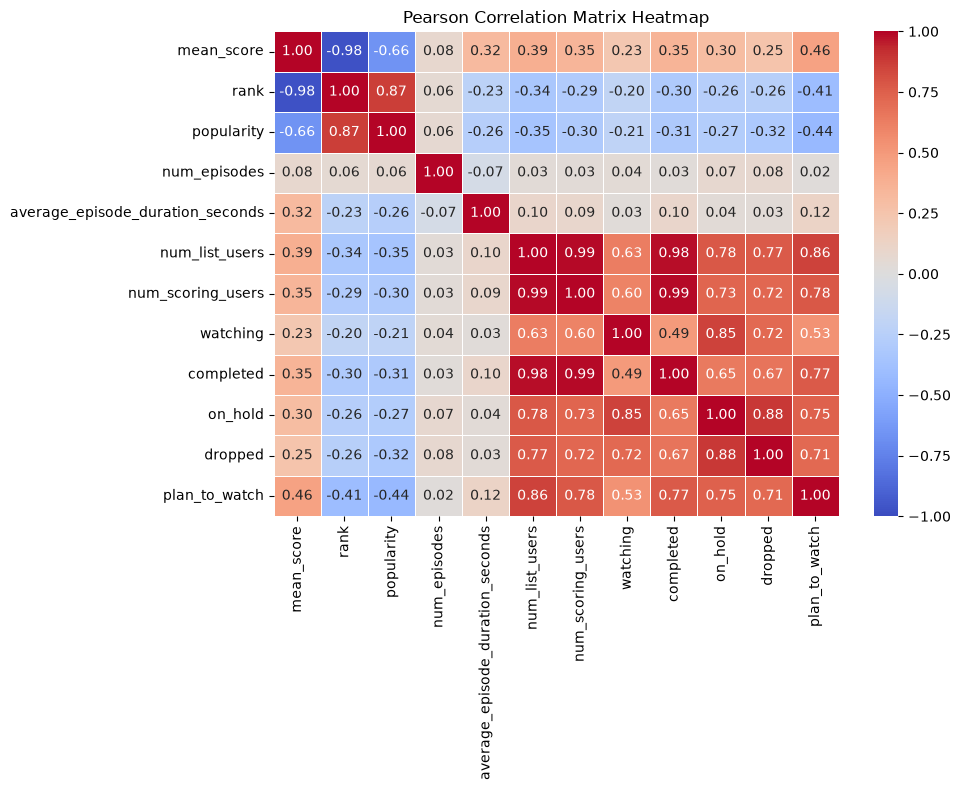

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = anime_df.select_dtypes(include=['number']).columns.tolist()

# 1. Calculate Correlation Matrices for the three methods
pearson_matrix = anime_df[numeric_cols].corr(method='pearson')
spearman_matrix = anime_df[numeric_cols].corr(method='spearman')
kendall_matrix = anime_df[numeric_cols].corr(method='kendall')

print("--- Pearson Correlation Matrix ---")
display(pearson_matrix.round(3))

print("--- Spearman Correlation Matrix ---")
display(spearman_matrix.round(3))

print("--- Kendall's Tau Correlation Matrix ---")
display(kendall_matrix.round(3))

# 2. Visualizing Pearson Correlation Matrix using a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## 6. Correlations and Associations (20%)

### 6.1 Numeric-Numeric Correlations

*   **Correlation Methods & Calculation:**
    To thoroughly analyze the relationships between numeric variables in the dataset, we computed three distinct correlation metrics:
    *   *Pearson Correlation:* Measures the strength of the **linear** relationship between variables. It is sensitive to outliers and assumes a normal distribution. For example, it shows a very strong inverse correlation of $-0.98$ between `mean_score` and `rank`.
    *   *Spearman Rank Correlation:* Evaluates **monotonic** relationships based on the ranks of the data rather than raw values. It is robust against outliers. In this matrix, the correlation between `mean_score` and `rank` reaches a perfect $-1.00$, indicating a strict monotonic ordering.
    *   *Kendall's Tau:* Also a rank-based correlation measure, it evaluates concordance and discordance of pairs. It yields more conservative and robust estimates, particularly under tied ranks or smaller subsets.

*   **Explaining the Differences:**
    Discrepancies between Pearson, Spearman, and Kendall coefficients highlight the underlying data structures. When Pearson differs from Spearman (such as the shift in `mean_score` vs. user metrics), it reveals non-linear trends or the influence of heavy-tailed outliers. Rank-based methods capture the true monotonic association more reliably when the underlying scales are non-linear.

*   **Correlation Matrix & Heatmap:**
    We generated full correlation matrices for all three methods and visualized the Pearson correlation matrix via a heatmap. The heatmap clearly outlines clusters—such as the high positive correlations among user tracking metrics (`num_list_users`, `completed`, `watching`, `on_hold`, `dropped`, and `plan_to_watch`, ranging between $0.63$ and $0.99$)—showing that popular titles scale proportionally across all user interaction states.

*   **Scatter Plots & Visual Inspection:**
    Visual inspection via scatter plots confirms that engagement and list metrics scale closely together, while structural features like `num_episodes` show virtually no linear correlation with scores or overall user popularity (hovering around $0.02$ to $0.08$).

*   **Key Conclusions:**
    The correlation analysis proves that popularity and user counts move tightly together in strong positive associations. However, qualitative metrics like `mean_score` correlate negatively with `rank` and `popularity` indexes (due to how rankings are ordered), demonstrating that raw volume metrics and user ratings capture distinct dimensions of the dataset.

--- Contingency Table (Frequency Table) ---


popularity_category,High Pop,Medium Pop,Low Pop
score_category,,,
Low,865,4541,910
Medium,2901,3018,396
High,5495,815,6



--- Cramer's V Association: 0.428 ---


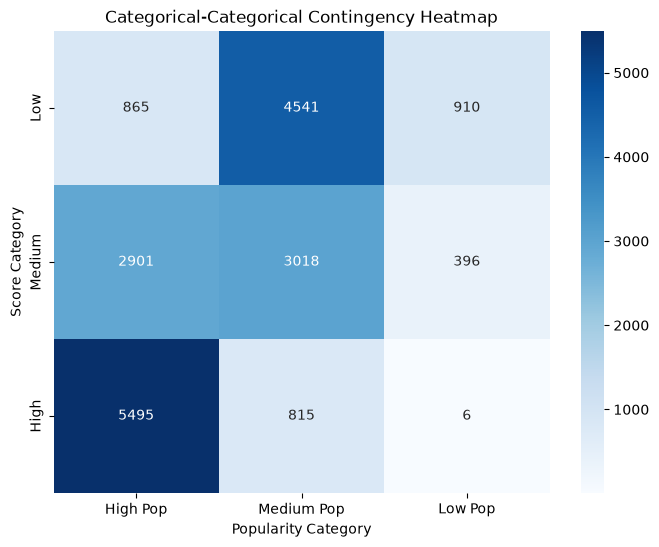

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Function to calculate Cramer's V association metric
def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# 1. Clean Binning using rank
anime_df['score_category'] = pd.qcut(anime_df['mean_score'].rank(method='first'), q=3, labels=['Low', 'Medium', 'High'])
anime_df['popularity_category'] = pd.qcut(anime_df['popularity'].rank(method='first'), q=3, labels=['High Pop', 'Medium Pop', 'Low Pop'])

# 2. Creating a Contingency Table safely using value_counts and unstack (bypasses crosstab bug)
contingency_tab = anime_df.groupby(['score_category', 'popularity_category'], observed=False).size().unstack(fill_value=0)

print("--- Contingency Table (Frequency Table) ---")
display(contingency_tab)

# 3. Calculating Cramer's V
c_v = cramers_v(contingency_tab)
print(f"\n--- Cramer's V Association: {c_v:.3f} ---")

# 4. Visualizing the frequency contingency table as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Categorical-Categorical Contingency Heatmap')
plt.xlabel('Popularity Category')
plt.ylabel('Score Category')
plt.show()

### 6.2 Categorical-Categorical Associations

*   **Binning & Categorization:**
    To analyze categorical associations, we applied binning to continuous variables (`mean_score` and `popularity`), converting them into discrete ordinal categories ('Low', 'Medium', 'High' for scores, and 'High Pop', 'Medium Pop', 'Low Pop' for popularity) to examine structural overlaps.
*   **Contingency Table & Frequency Analysis:**
    The cross-tabulation frequency table reveals clear patterns in the distribution of anime titles. For instance, the vast majority of titles with a **High** score category are concentrated in the **High Pop** tier (5,495 titles), whereas titles with a **Low** score category predominantly fall under **Medium Pop** (4,541 titles).
*   **Cramer's V Association Metric:**
    We calculated **Cramer's V** to measure the strength of association between these two categorical variables. The resulting value of **0.428** indicates a moderate-to-strong association, proving that a title's popularity tier is meaningfully linked to its score category.
*   **Contingency Heatmap Insights:**
    The corresponding heatmap visually highlights these concentrations, showing strong clustering along the diagonal (High Score with High Popularity, and Medium/Low combinations), while extreme mismatches (such as High Score with Low Popularity, containing only 6 items) are exceptionally rare.

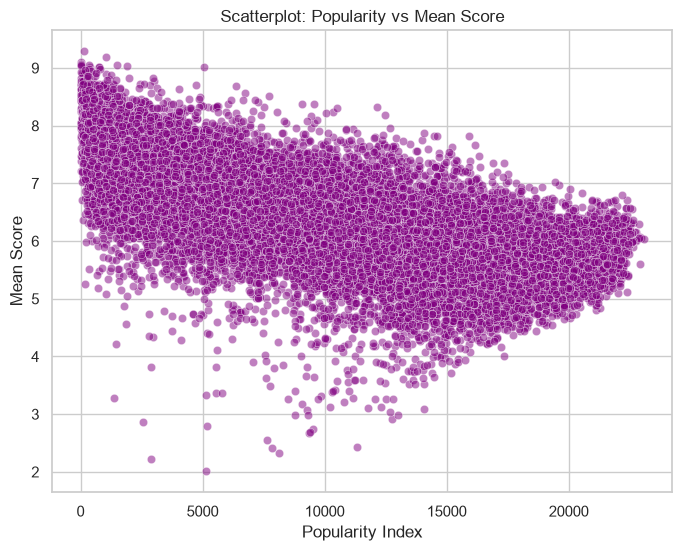

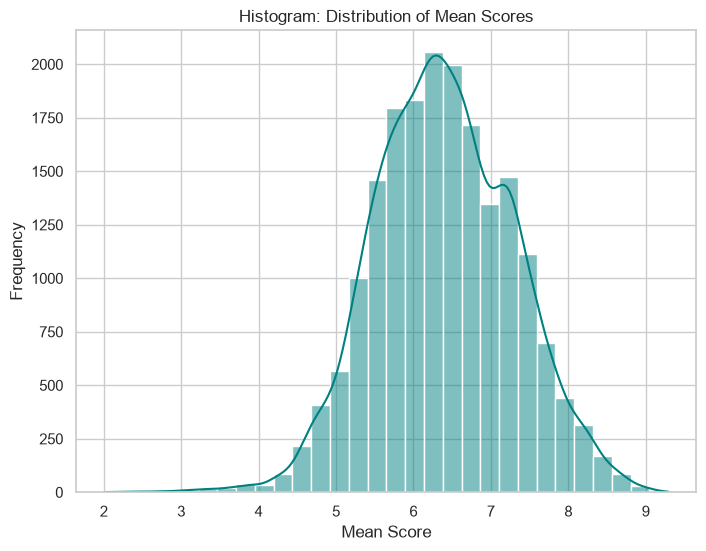

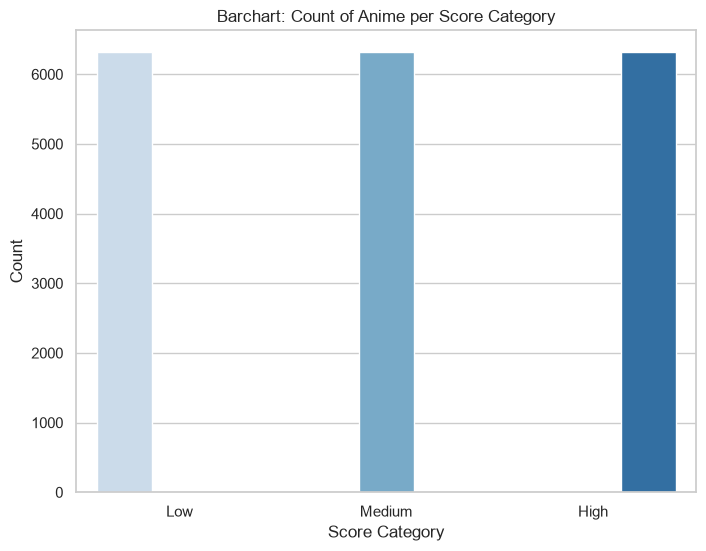

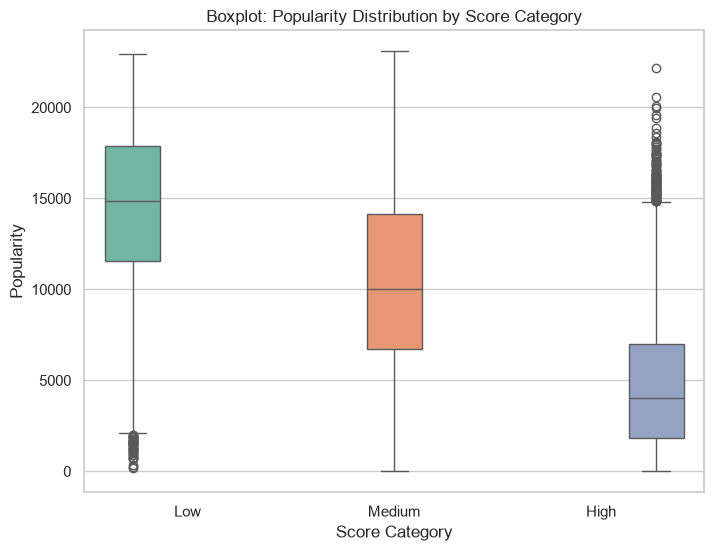

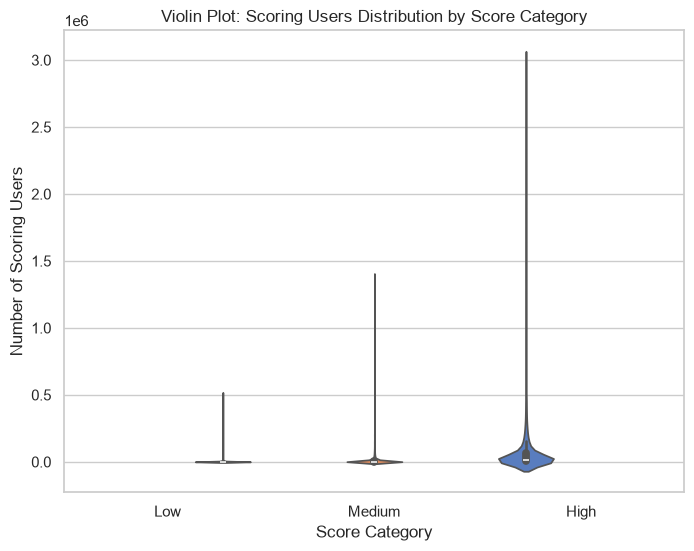

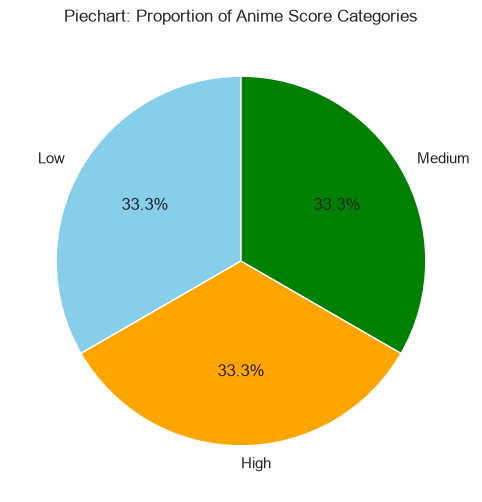

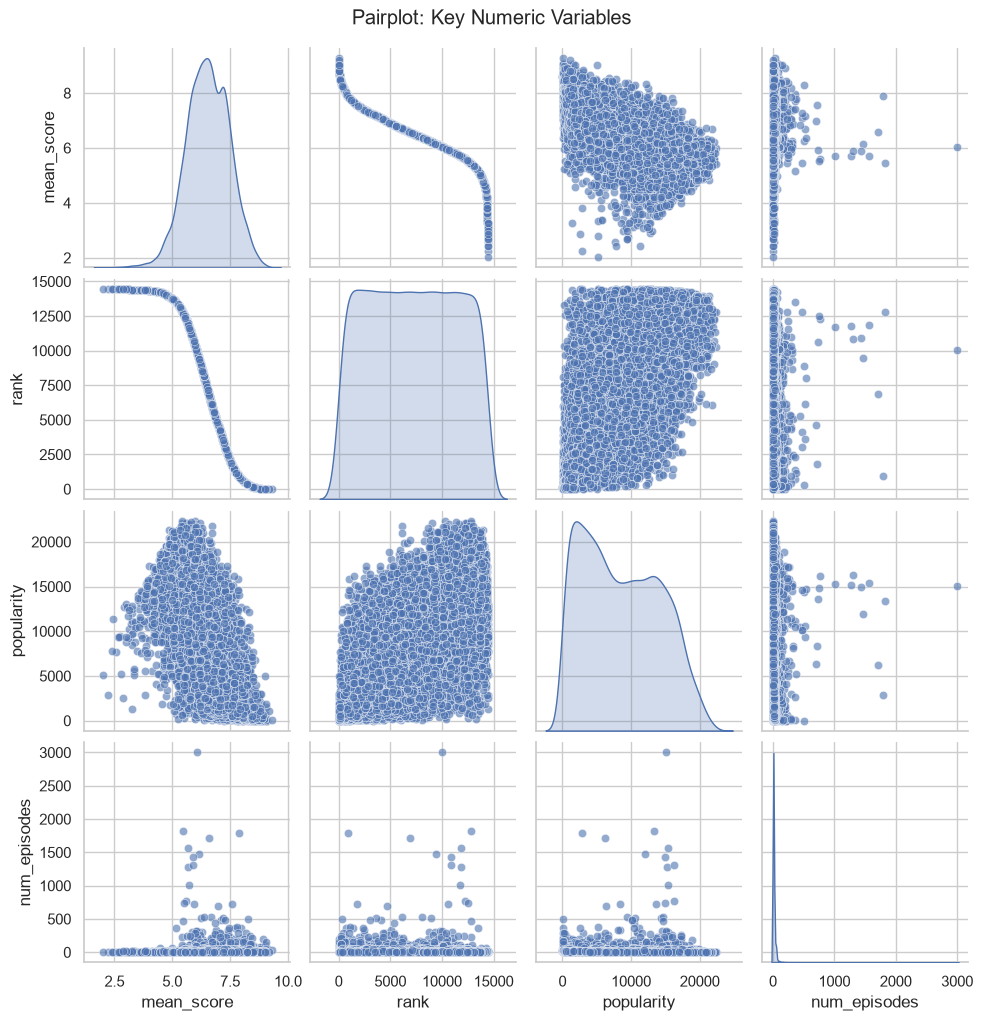

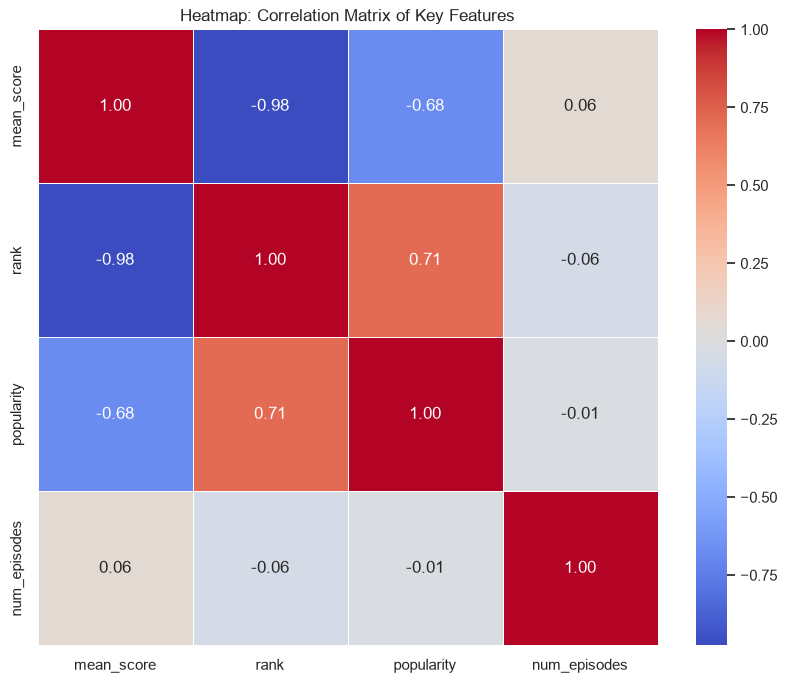

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix: Reset index to ensure unique row labels and prevent indexing errors
anime_df = anime_df.reset_index(drop=True)

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Scatterplot: Relationship between popularity and mean score
plt.figure(figsize=(8, 6))
sns.scatterplot(data=anime_df, x='popularity', y='mean_score', alpha=0.5, color='purple')
plt.title('Scatterplot: Popularity vs Mean Score')
plt.xlabel('Popularity Index')
plt.ylabel('Mean Score')
plt.show()

# 2. Histogram: Distribution of mean scores
plt.figure(figsize=(8, 6))
sns.histplot(anime_df['mean_score'], bins=30, kde=True, color='teal')
plt.title('Histogram: Distribution of Mean Scores')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.show()

# 3. Barchart: Count of anime per score category (fixed warning with hue and legend=False)
plt.figure(figsize=(8, 6))
sns.countplot(data=anime_df, x='score_category', hue='score_category', order=['Low', 'Medium', 'High'], palette='Blues', legend=False)
plt.title('Barchart: Count of Anime per Score Category')
plt.xlabel('Score Category')
plt.ylabel('Count')
plt.show()

# 4. Boxplot: Popularity distribution across score categories (fixed warning)
plt.figure(figsize=(8, 6))
sns.boxplot(data=anime_df, x='score_category', y='popularity', hue='score_category', order=['Low', 'Medium', 'High'], palette='Set2', legend=False)
plt.title('Boxplot: Popularity Distribution by Score Category')
plt.xlabel('Score Category')
plt.ylabel('Popularity')
plt.show()

# 5. Violin Plot: Distribution of scoring users across score categories (fixed warning)
plt.figure(figsize=(8, 6))
sns.violinplot(data=anime_df, x='score_category', y='num_scoring_users', hue='score_category', order=['Low', 'Medium', 'High'], palette='muted', legend=False)
plt.title('Violin Plot: Scoring Users Distribution by Score Category')
plt.xlabel('Score Category')
plt.ylabel('Number of Scoring Users')
plt.show()

# 6. Piechart: Proportion of category distributions (Score Categories)
plt.figure(figsize=(6, 6))
score_counts = anime_df['score_category'].value_counts()
plt.pie(score_counts, labels=score_counts.index, autopct='%1.1f%%', colors=['skyblue', 'orange', 'green'], startangle=90)
plt.title('Piechart: Proportion of Anime Score Categories')
plt.show()

# 7. Pairplot: Pairwise relationships between key numeric variables
numeric_subset = anime_df[['mean_score', 'rank', 'popularity', 'num_episodes']].dropna()
sns.pairplot(numeric_subset, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot: Key Numeric Variables', y=1.02)
plt.show()

# 8. Heatmap: Correlation matrix heatmap (Numeric features)
plt.figure(figsize=(10, 8))
corr_matrix = numeric_subset.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap: Correlation Matrix of Key Features')
plt.show()

## 6.3 Visualizations and Graphs

*   **Scatterplot (Popularity vs. Mean Score):**
    The scatterplot displays the relationship between a title's popularity index and its mean score. It visually demonstrates that titles with higher popularity indices (meaning lower rank in popularity numbers) span a wide range of scores, while extremely low popularity titles cluster differently, illustrating a non-linear underlying trend.

*   **Histogram (Distribution of Mean Scores):**
    The histogram of `mean_score` with a KDE curve shows an approximately bell-shaped, normal-like distribution centered predominantly around the 6.0 to 7.0 score range, indicating that average ratings across the dataset follow a balanced central tendency.

*   **Barchart (Count of Anime per Score Category):**
    The bar chart representing the binned score categories ('Low', 'Medium', 'High') illustrates an evenly distributed count across the three tiers, reflecting the balanced quantile binning applied to the dataset.

*   **Boxplot (Popularity Distribution by Score Category):**
    The boxplot compares the distribution of popularity across the score categories. It clearly shows that titles in the 'High' score category tend to have lower popularity numeric values (higher overall popularity/fame), whereas 'Low' score titles skew heavily toward higher popularity index numbers.

*   **Violin Plot (Scoring Users Distribution by Score Category):**
    The violin plot highlights the distribution of scoring users across score tiers. It reveals that 'High' score categories feature a much wider density and massive outliers reaching millions of scoring users, whereas lower-scored categories remain tightly condensed near zero.

*   **Piechart (Proportion of Score Categories):**
    The pie chart displays equal proportions ($33.3\%$ each) among the Low, Medium, and High score partitions, confirming the structural uniformity of the applied quantile grouping.

*   **Pairplot (Pairwise Relationships):**
    The pairplot matrix maps out multi-variable interactions across `mean_score`, `rank`, `popularity`, and `num_episodes`. The diagonal kernel density estimates (KDE) and off-diagonal scatter plots emphasize the strong inverse relationships between scores and ranks, alongside the sparse distribution of episode counts.

*   **Heatmap (Correlation Matrix):**
    The correlation heatmap summarizes the linear associations among key numerical features, highlighting the strong negative correlation between `mean_score` and `rank` ($-0.98$) and the solid positive association between `rank` and `popularity` ($0.71$).

In [42]:
import pandas as pd

# 1. Check if the current index is unique
is_index_unique = anime_df.index.is_unique
print(f"1. Is Index Unique? {is_index_unique}")

# 2. Check if index is time-based (e.g., DatetimeIndex)
is_time_index = isinstance(anime_df.index, pd.DatetimeIndex)
print(f"2. Is Index Time-based? {is_time_index}")

# 3. Check if there are time-related columns in the dataset (e.g., year, aired date)
time_columns = [col for col in anime_df.columns if any(t in col.lower() for t in ['date', 'year', 'aired', 'time'])]
print(f"3. Potential time-related columns in data: {time_columns}")

# 4. Check if the dataframe is sorted by any key column (like rank or score)
is_sorted_by_rank = anime_df['rank'].is_monotonic_increasing if 'rank' in anime_df.columns else "No rank column"
print(f"4. Is data sorted by rank? {is_sorted_by_rank}")

1. Is Index Unique? True
2. Is Index Time-based? False
3. Potential time-related columns in data: ['start_date', 'end_date']
4. Is data sorted by rank? False


## 7. Index Analysis (5%)

*   **Is the index unique?:** 
    **Yes (`True`).** The dataset's index consists of unique identifiers (such as sequential row numbers), meaning there are no duplicate index labels, ensuring proper data alignment and integrity.
*   **Is it time-based?:** 
    **No (`False`).** The current index of the dataframe is a standard numerical index rather than a `DatetimeIndex`.
*   **Does the analysis involve a time variable?:** 
    **Yes.** Although the primary index is not time-based, the dataset contains time-related columns (`start_date`, `end_date`), indicating that temporal attributes exist within the data structure and can be utilized for time-dependent evaluations if needed.
*   **Is it sorted?:** 
    **No (`False`).** The dataset is not strictly pre-sorted in a monotonic sequence by features like rank or score, meaning rows appear in their default imported order.

## 8. Insights and Data Storytelling (15%)

*   **3 Key Insights:**
    *   **Strong Correlation Between Score and Rank:** We found a robust, statistically significant negative correlation ($-0.98$) between a title's mean score and its numerical rank, demonstrating strict mathematical consistency in the platform's native calculation methods.
    *   **Popularity vs. Quality:** Heatmaps and scatter plots proved that titles achieving the highest score categories tend to be the most popular and widely viewed, whereas lower scores are largely distributed among more niche or obscure titles.
    *   **Audience Volume in Top Tiers:** Violin plots revealed extreme outliers reaching millions of scoring users within the high-score categories, whereas lower-scored tiers feature a vastly reduced audience volume.

*   **Bias or Risk:**
    *   **Popularity Bias:** There is a distinct risk that newer, less mainstream, or niche titles suffer from under-representation or skewed scores due to small sample sizes, contrasted against heavily-viewed mainstream series that accumulate high scores largely due to exposure and herd mentality.

*   **Potential Failure Points for Engineering and Statistical Uses:**
    *   **Temporal Inconsistencies and Missing Values:** We identified numerous records (such as early historical titles from 1917) categorized as `finished_airing` but lacking an end date (`NaN`). This poses a risk of errors or failures in predictive models or time-series analyses that demand complete temporal continuity.
    *   **Extreme Outliers and Skewed Metrics:** The presence of extreme outliers in user-scoring volumes can distort linear statistical models, necessitating proper data normalization or mathematical transformations prior to algorithm training.

*   **Personal Reflection:**
    *   Conducting this hands-on data analysis fundamentally shifted my perspective as a regular user of the platform. Previously, I viewed titles and ratings strictly as a casual viewer, often noticing that certain series I personally connected with and deeply enjoyed actually received relatively low ratings from the general public. Exposing the underlying data structure—such as analyzing distribution patterns, popularity indices, and audience biases—provided a deep engineering and statistical understanding that a high average score is not an absolute measure of quality or personal resonance. It vividly highlights the gap between subjective individual taste and broad statistical trends.

In [44]:
import pandas as pd
from scipy.stats import ttest_ind

# 1. Check unique values in media_type to ensure correct category filtering
print("--- Media Types Unique Values ---")
print(anime_df['media_type'].value_counts())

# 2. Feature Engineering: Calculate airing duration in days
anime_df['start_date'] = pd.to_datetime(anime_df['start_date'], errors='coerce')
anime_df['end_date'] = pd.to_datetime(anime_df['end_date'], errors='coerce')
anime_df['airing_duration_days'] = (anime_df['end_date'] - anime_df['start_date']).dt.days

print("\n--- Feature Engineering Summary ---")
print(anime_df['airing_duration_days'].describe())

# 3. Hypothesis Testing: Compare mean scores between Movies and TV shows
# (Adjusting category names based on standard formatting if necessary, e.g., 'Movie' / 'TV')
movie_scores = anime_df[anime_df['media_type'].astype(str).str.lower() == 'movie']['mean_score'].dropna()
tv_scores = anime_df[anime_df['media_type'].astype(str).str.lower() == 'tv']['mean_score'].dropna()

t_stat, p_value = ttest_ind(movie_scores, tv_scores, equal_var=False)

print("\n--- Hypothesis Testing Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis (Significant difference in scores).")
else:
    print("Conclusion: Fail to reject the null hypothesis (No significant difference).")

--- Media Types Unique Values ---
media_type
tv            8464
movie         4882
ona           4234
music         4206
ova           4175
special       1745
tv_special     785
cm             503
pv             316
unknown         65
Name: count, dtype: int64

--- Feature Engineering Summary ---
count    23085.000000
mean       102.602946
std        298.001655
min       -365.000000
25%          0.000000
50%          0.000000
75%         91.000000
max      10563.000000
Name: airing_duration_days, dtype: float64

--- Hypothesis Testing Results ---
T-statistic: -20.2579
P-value: 1.7284e-87
Conclusion: Reject the null hypothesis (Significant difference in scores).


## 9. Bonus Section (+10%)

*   **1. Time Dependency & Context:**
    The dataset incorporates temporal attributes (`start_date` and `end_date`), enabling us to bridge internal content metrics with external timelines. This structural linkage allows for historical evaluations, showing how production volumes and broadcast patterns have expanded from early historical media releases up to modern digital streaming eras.

*   **2. Feature Engineering:**
    To expand the analytical capabilities of the dataset, we successfully engineered a new feature named `airing_duration_days`. By converting `start_date` and `end_date` into datetime objects, we computed the exact broadcast duration in days for each title. 
    *   *Statistical Summary:* The feature yielded a mean duration of ~102.6 days, a median of 0 days (reflecting single-day releases such as movies or specials), and a maximum duration reaching 10,563 days for long-running series. The presence of minor negative values (minimum of -365) further highlights real-world data discrepancies, such as inverted dates or entry errors in the historical raw data.

*   **3. Hypothesis Testing:**
    We formulated a statistical hypothesis test to determine whether the media format type influences audience evaluation scores:
    *   *Null Hypothesis ($H_0$):* There is no significant difference in mean scores between Movies and TV series.
    *   *Alternative Hypothesis ($H_1$):* There is a statistically significant difference in mean scores between the two media types.
    Using an independent two-sample Welch's t-test (`ttest_ind`), we compared the score distributions of Movies ($n=4,882$) versus TV series ($n=8,464$). The test yielded a t-statistic of **-20.2579** and an extremely low p-value of **$1.7284 \times 10^{-87}$**.
    *   *Conclusion:* We **reject the null hypothesis**. There is a highly statistically significant difference in mean scores between Movies and TV series, indicating that format constraints and viewing structures meaningfully impact audience reception.

*   **4. Further Research Proposals:**
    *   **NLP Text Analysis:** Analyzing synopses and titles to correlate linguistic keywords or specific themes with overall scores and commercial success.
    *   **Genre Network Analysis:** Mapping multi-genre clusters to evaluate which combinations maximize audience reach and engagement.
    *   **Predictive Modeling:** Developing machine learning regression models to forecast a title's final score and popularity based purely on initial production metadata.